In [1]:
import warnings
warnings.filterwarnings('ignore')

In [18]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.datasets import fashion_mnist

import helper

In [3]:
# Loading the data
(train_data, train_labels),(test_data, test_labels) =  fashion_mnist.load_data()

In [4]:
# Shape of the Data
print(f"Shape of train_data: {train_data.shape}")
print(f"Shape of test_data: {test_data.shape}")

Shape of train_data: (60000, 28, 28)
Shape of test_data: (10000, 28, 28)


In [5]:
# Shape of a Sample
print(f"Shape of TrainData Sample: {train_data[0].shape}")
print(f"Shape of TrainData Lable: {train_labels[0].shape}")

Shape of TrainData Sample: (28, 28)
Shape of TrainData Lable: ()


In [6]:
# Sample of Data
print(f"Training Sample:\n{train_data[0]}\n")
print(f"Training label:\n{train_labels[0]}\n")

Training Sample:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1  

In [7]:
# Adding Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

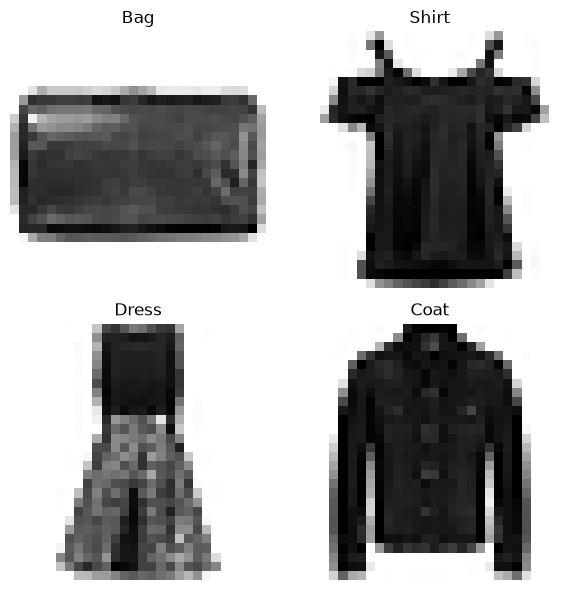

In [8]:
# Random Sample Image of the Training Data
fig, ax = plt.subplots(2, 2, figsize=(6, 6))
ax = ax.ravel()
for i in range(4):
    random_index = np.random.randint(0, len(train_data))
    ax[i].imshow(train_data[random_index], cmap="binary")
    ax[i].set_title(class_names[train_labels[random_index]])
    ax[i].axis("off")

plt.tight_layout()
plt.show()


In [9]:
# Findings
print(f"Input Shape of the model will be: {28 * 28}")
print(f"Output Shape of the model will be: {10}")

Input Shape of the model will be: 784
Output Shape of the model will be: 10


## Activation Function Softmax

$\boxed{ P(y=i)= \frac{e^{z_i}} {\sum_{j=1}^{n}e^{z_j}} }$

In [10]:
import numpy as np

def softmax(z):
    z = z - np.max(z)
    exp_z = np.exp(z)
    softmax = exp_z / np.sum(exp_z)
    return softmax

logits = np.array([1, 2, 3])
print(softmax(logits))

[0.09003057 0.24472847 0.66524096]


# Building Multiclass Classification Model



In [11]:
# splitting data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    train_data,
    train_labels,
    test_size=0.3,
    random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (42000, 28, 28)
Shape of y_train: (42000,)
Shape of X_test: (18000, 28, 28)
Shape of y_test: (18000,)


In [12]:
# Model 1

# 1. set the random seed
tf.random.set_seed(42)

# 2. Creating the model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
], name="Model_1")

# 3. Compile the model_1
model_1.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

# 4. Fitting the model_1
history_1 = model_1.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10
)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2155 - loss: 2.2026 - val_accuracy: 0.2443 - val_loss: 1.8013
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2610 - loss: 1.7474 - val_accuracy: 0.2791 - val_loss: 1.6936
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2835 - loss: 1.6715 - val_accuracy: 0.2962 - val_loss: 1.6501
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2957 - loss: 1.6422 - val_accuracy: 0.3127 - val_loss: 1.6159
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3056 - loss: 1.6142 - val_accuracy: 0.3113 - val_loss: 1.5988
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3099 - loss: 1.5922 - val_accuracy: 0.3061 - val_loss: 1.5920
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3124 - loss: 1.5813 - val_accuracy: 0.3173 - val_loss: 1.5737
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3144 - loss: 1.5737 - 

Model: "Model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            60 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,897 (93.35 KB)

 Trainable params: 7,965 (31.11 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,932 (62.24 KB)

None


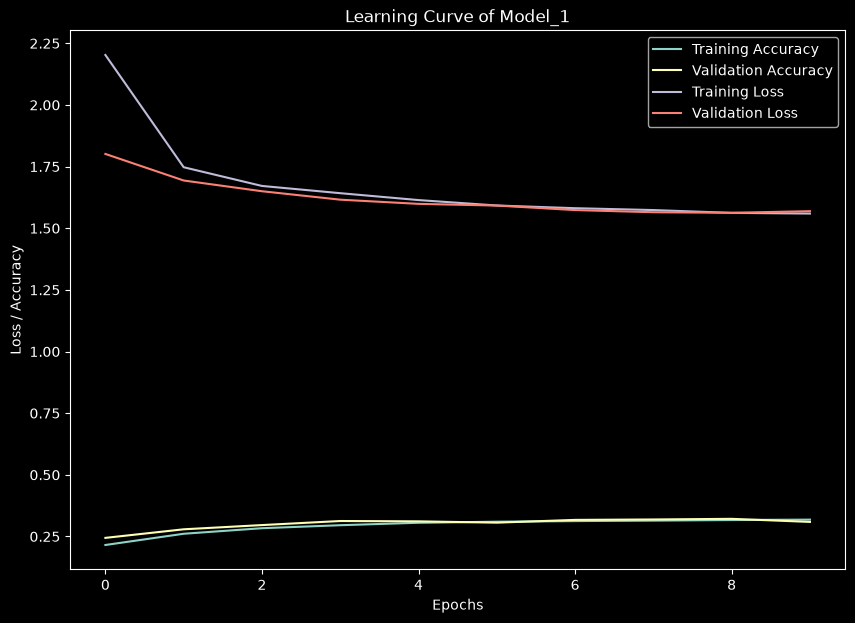

In [21]:
summary, figure = helper.model_summary(
    model= model_1,
    history= history_1
)

print(summary)
figure.show()